In [1]:
%load_ext autoreload
%autoreload 2
from helpers import *
from SINDyModel import *

In [2]:
def generate_noise_level_vs_dt_matrix(rhs, x0, t_span, noise_levels, dts,
                                      threshold=0.05, poly_order=5, generate_prediction=True,
                                      generate_more_derivatives=True):
    # we will return data as a 2d matrix of dictionaries
    # results[row][col] will be a dictionary of results for the test with dt=dts[row] and noise_level=noise_levels[col]

    # initialize the data matrix with None entries
    results = [[None for _ in range(len(noise_levels))] for _ in range(len(dts))]

    for i, dt in enumerate(dts):
        print(f"dt: {dt}")

        for j, noise_level in enumerate(tqdm(noise_levels)):
            result = {}

            # generate evaluation time points
            t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
            result["t_eval"] = t_eval

            # generate training data
            x_train = generate_training_data(rhs, x0, t_eval)
            result["x_train"] = x_train
            
            # generate noisy data
            x_train_noisy = add_noise_to_data(x_train, noise_level)
            result["x_train_noisy"] = x_train_noisy

            # generate the derivative of the noisy data using finite difference
            x_dot_finite_difference = dxdt(x_train_noisy, t_eval, kind="finite_difference", k=1)
            result["x_dot_finite_difference"] = x_dot_finite_difference

            # generate the true derivative of the data
            # this is only used for comparison and is not used in the SINDy model
            x_dot_true = generate_true_derivative(rhs, x_train)
            result["x_dot_true"] = x_dot_true

            # generate different derivative approximations if needed
            if generate_more_derivatives is True:
                x_dot_savitzky_golay = dxdt(x_train_noisy, t_eval, kind="savitzky_golay", left=.5, right=.5, order=3)
                result['x_dot_savitzky_golay'] = x_dot_savitzky_golay
            
            # create and fit a SINDy model
            model = SINDyModel(n_state_vars=len(x0), threshold=threshold, poly_order=poly_order)
            model.fit(x_train_noisy, x_dot_finite_difference)
            result["model"] = model

            # generate the model prediction if needed
            if generate_prediction is True:
                x_pred = generate_model_prediction(model, x0, t_eval)
                result["x_pred"] = x_pred
            
            # store the data entry
            results[i][j] = result
        
    return results


lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

# noise_levels = [0, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 1]
# dts = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]
noise_levels = np.logspace(-4, 0, 10).tolist()
dts = np.logspace(-2, 0, 11).tolist()

results = generate_noise_level_vs_dt_matrix(
    rhs=lotka_volterra_rhs,
    x0=(10, 5),
    t_span=(0, 50),
    noise_levels=noise_levels,
    dts=dts,
    generate_prediction=False
)


dt: 0.01


100%|██████████| 10/10 [00:31<00:00,  3.13s/it]


dt: 0.015848931924611134


100%|██████████| 10/10 [00:20<00:00,  2.01s/it]


dt: 0.025118864315095794


...

100%|██████████| 10/10 [00:01<00:00,  6.98it/s]


dt: 0.6309573444801934


100%|██████████| 10/10 [00:01<00:00,  7.71it/s]


dt: 1.0


100%|██████████| 10/10 [00:00<00:00, 10.47it/s]


In [3]:
# make labels for use in the following heatmaps
xticklabels = [f"{dt:.3f}\n{i}" for i, dt in enumerate(dts)]
yticklabels = [f"{noise_level:.5f}\n{i}" for i, noise_level in list(enumerate(noise_levels))[::-1]]

In [4]:
# make a matrix of the relative squared errors

def relative_squared_error_matrix(deriv_kind):
    relative_squared_error_mtx = np.zeros((len(dts), len(noise_levels)))

    for i in range(len(dts)):
        for j in range(len(noise_levels)):
            data_entry = results[i][j]
            x_dot_true = data_entry["x_dot_true"]
            x_dot_finite_difference = data_entry["x_dot_" + deriv_kind]

            # compute the relative squared error
            rse = relative_squared_error(x_dot_true, x_dot_finite_difference)
            
            # store the relative squared error in the matrix
            relative_squared_error_mtx[i, j] = rse
    
    # flip the matrices so that the smallest dt and noise level are in the bottom left corner
    relative_squared_error_mtx = relative_squared_error_mtx[:, ::-1].T

    return relative_squared_error_mtx


relative_squared_error_mtx_finite_difference = relative_squared_error_matrix("finite_difference")
relative_squared_error_mtx_savitzky_golay = relative_squared_error_matrix("savitzky_golay")

[Text(0.5, 25.649999999999984, 'dt'),
 Text(59.64999999999999, 0.5, 'noise level'),
 Text(0.5, 1.0, 'Relative Squared Error for Savitzky Golay')]

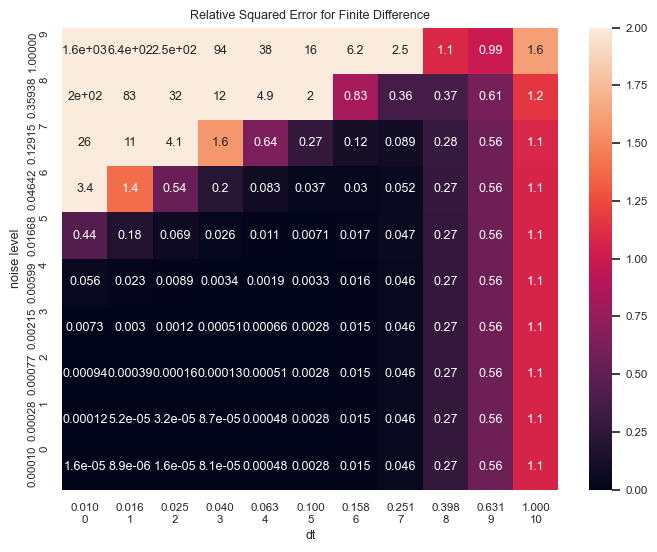

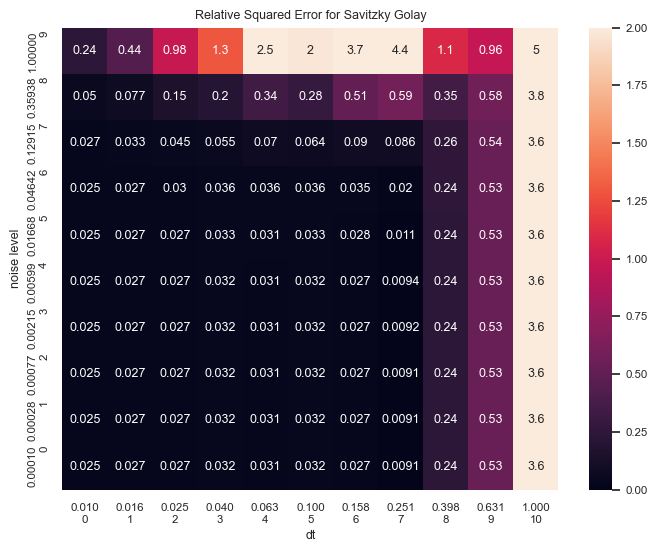

In [5]:
import seaborn as sns

sns.set_theme(font_scale=0.75)

fig = plt.figure(figsize=(8, 6))
ax = sns.heatmap(relative_squared_error_mtx_finite_difference, annot=True,
                 xticklabels=xticklabels, yticklabels=yticklabels, vmin=0, vmax=2)
ax.set(xlabel='dt', ylabel='noise level', title="Relative Squared Error for Finite Difference")

fig = plt.figure(figsize=(8, 6))
ax = sns.heatmap(relative_squared_error_mtx_savitzky_golay, annot=True,
                 xticklabels=xticklabels, yticklabels=yticklabels, vmin=0, vmax=2)
ax.set(xlabel='dt', ylabel='noise level', title="Relative Squared Error for Savitzky Golay")

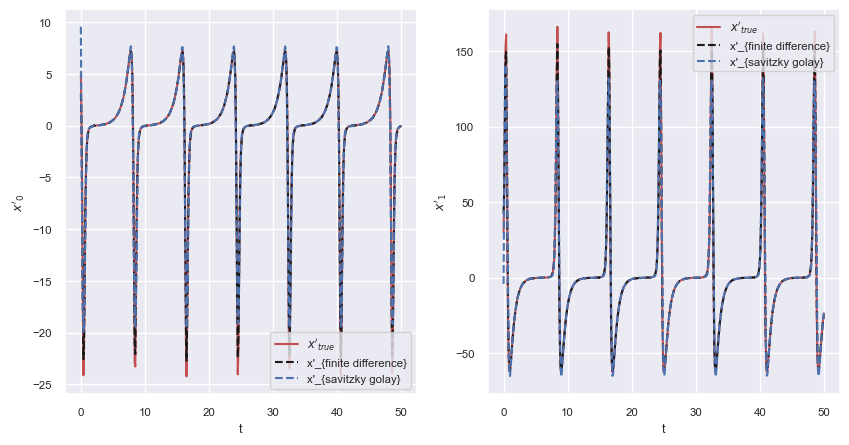

In [6]:
# set the indices of the data entry you'd like to explore
dt_idx = 5
noise_level_idx = 2

# extract the relevant data from the data entry
result = results[dt_idx][noise_level_idx]
t_eval = result['t_eval']
x_dot_true = result['x_dot_true']
x_dot_finite_difference = result['x_dot_finite_difference']
x_dot_savitzky_golay = result['x_dot_savitzky_golay']

n_state_vars = x_dot_true.shape[0]

# plot the training data and model prediction
fig, axs = plt.subplots(1, n_state_vars, figsize=(10, 5))

for sv in range(n_state_vars):
    axs[sv].plot(t_eval, x_dot_true[sv], "r", label="$x'_{true}$")
    axs[sv].plot(t_eval, x_dot_finite_difference[sv], "k--", label="x'_{finite difference}")
    axs[sv].plot(t_eval, x_dot_savitzky_golay[sv], "b--", label="x'_{savitzky golay}")

    # set labels
    axs[sv].set_xlabel("t")
    axs[sv].set_ylabel(f"$x'_{sv}$")
    axs[sv].legend()